## Import Library

In [112]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random


In [113]:
df = pd.read_csv("car_evaluation.csv")

In [114]:
df.columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

In [115]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


## Distribusi Kelas

In [116]:
print(df['class'].value_counts())

class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [117]:
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

In [118]:
df.duplicated().sum()

0

In [119]:
df.dtypes

buying      object
maint       object
doors       object
persons     object
lug_boot    object
safety      object
class       object
dtype: object

In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   object
 3   persons   1727 non-null   object
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   class     1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [121]:
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()
for col in df.columns:
    df[col] = labelencoder.fit_transform(df[col])




In [122]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,2,2
1,3,3,0,0,2,0,2
2,3,3,0,0,1,1,2
3,3,3,0,0,1,2,2
4,3,3,0,0,1,0,2


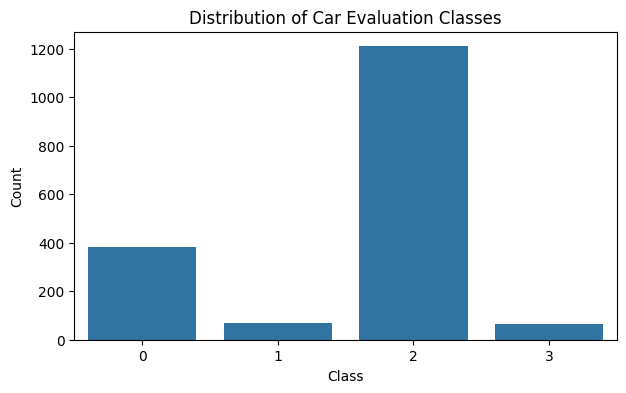

In [128]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='class')
plt.title("Distribution of Car Evaluation Classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

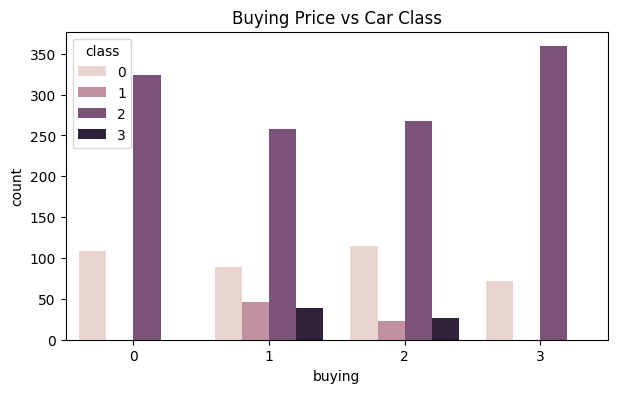

In [129]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='buying', hue='class')
plt.title("Buying Price vs Car Class")
plt.show()

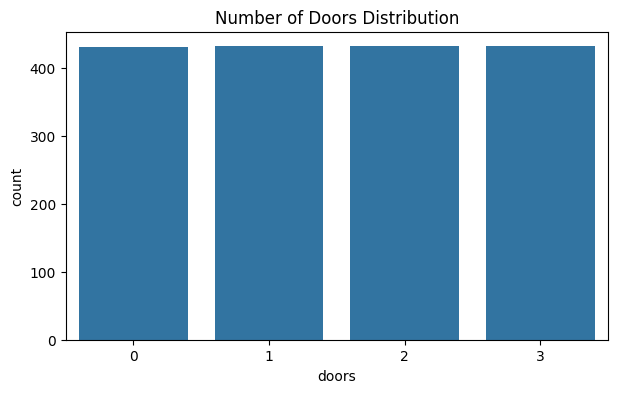

In [130]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='doors')
plt.title("Number of Doors Distribution")
plt.show()

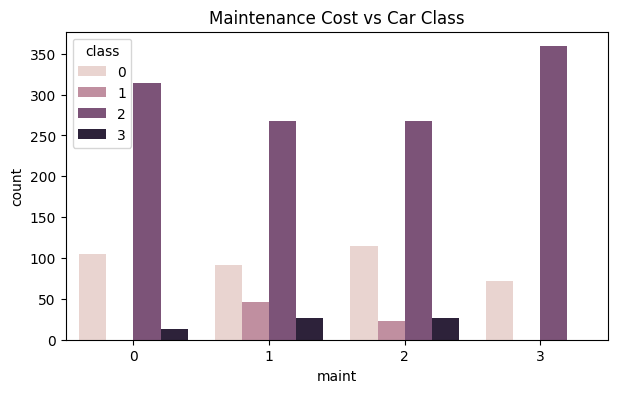

In [131]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='maint', hue='class')
plt.title("Maintenance Cost vs Car Class")
plt.show()

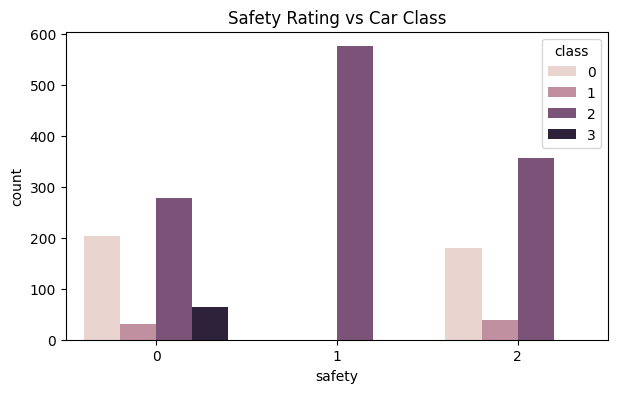

In [132]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='safety', hue='class')
plt.title("Safety Rating vs Car Class")
plt.show()

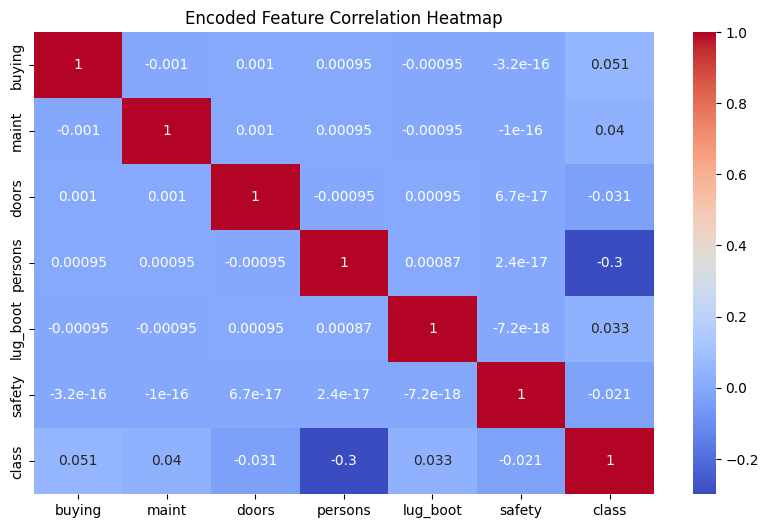

In [133]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.apply(LabelEncoder().fit_transform)

plt.figure(figsize=(10,6))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")
plt.title("Encoded Feature Correlation Heatmap")
plt.show()

In [123]:
def train_test_split(X, y, test_size=0.2):
    indices = np.arange(len(X))
    np.random.shuffle(indices)

    split = int(len(X) * (1 - test_size))
    train_idx, test_idx = indices[:split], indices[split:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


X_train, X_test, y_train, y_test = train_test_split(X, y)


In [124]:
class NaiveBayes:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.class_prob = {}
        self.feature_prob = {}

        for cls in self.classes:
            X_cls = X[y == cls]
            self.class_prob[cls] = len(X_cls) / len(X)

            self.feature_prob[cls] = []
            for i in range(X.shape[1]):
                values, counts = np.unique(X_cls[:, i], return_counts=True)
                total = sum(counts)
                probs = {}

                for v, c in zip(values, counts):
                    probs[v] = (c + self.alpha) / (total + self.alpha * len(values))

                self.feature_prob[cls].append(probs)

    def predict(self, X):
        predictions = []

        for x in X:
            posteriors = {}

            for cls in self.classes:
                posterior = np.log(self.class_prob[cls])

                for i, val in enumerate(x):
                    probs = self.feature_prob[cls][i]
                    posterior += np.log(probs.get(val, self.alpha / (self.alpha + 1)))

                posteriors[cls] = posterior

            predictions.append(max(posteriors, key=posteriors.get))

        return np.array(predictions)


In [125]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


In [126]:
def genetic_algorithm(X_train, y_train, X_val, y_val,
                      pop_size=10, generations=200, mutation_rate=0.1):

    population = [random.uniform(0.01, 5) for _ in range(pop_size)]

    for gen in range(generations):
        fitness = []

        for alpha in population:
            model = NaiveBayes(alpha=alpha)
            model.fit(X_train, y_train)
            preds = model.predict(X_val)
            acc = accuracy(y_val, preds)
            fitness.append((acc, alpha))

        fitness.sort(reverse=True)
        population = [alpha for _, alpha in fitness[:pop_size // 2]]

        # Crossover
        while len(population) < pop_size:
            p1, p2 = random.sample(population[:5], 2)
            child = (p1 + p2) / 2

            # Mutation
            if random.random() < mutation_rate:
                child += random.uniform(-0.5, 0.5)

            child = max(0.01, min(child, 5))
            population.append(child)

        print(f"Generasi {gen+1} | Best Accuracy: {fitness[0][0]:.4f} | Alpha: {fitness[0][1]:.4f}")

    return fitness[0][1]


In [127]:
best_alpha = genetic_algorithm(
    X_train, y_train,
    X_test, y_test
)

print("\nBest Alpha:", best_alpha)

final_model = NaiveBayes(alpha=best_alpha)
final_model.fit(X_train, y_train)

final_preds = final_model.predict(X_test)
final_acc = accuracy(y_test, final_preds)

print("Final Accuracy:", final_acc)


Generasi 1 | Best Accuracy: 0.8035 | Alpha: 0.5446
Generasi 2 | Best Accuracy: 0.8035 | Alpha: 0.5446
Generasi 3 | Best Accuracy: 0.8035 | Alpha: 0.5446
Generasi 4 | Best Accuracy: 0.8035 | Alpha: 0.5446
Generasi 5 | Best Accuracy: 0.8035 | Alpha: 0.5446
Generasi 6 | Best Accuracy: 0.8035 | Alpha: 0.5446
Generasi 7 | Best Accuracy: 0.8035 | Alpha: 0.5446
Generasi 8 | Best Accuracy: 0.8035 | Alpha: 0.5446
Generasi 9 | Best Accuracy: 0.8035 | Alpha: 0.5446
Generasi 10 | Best Accuracy: 0.8035 | Alpha: 0.5446
Generasi 11 | Best Accuracy: 0.8035 | Alpha: 0.5748
Generasi 12 | Best Accuracy: 0.8035 | Alpha: 0.5748
Generasi 13 | Best Accuracy: 0.8035 | Alpha: 0.5748
Generasi 14 | Best Accuracy: 0.8035 | Alpha: 0.5748
Generasi 15 | Best Accuracy: 0.8035 | Alpha: 0.5748
Generasi 16 | Best Accuracy: 0.8035 | Alpha: 0.5748
Generasi 17 | Best Accuracy: 0.8035 | Alpha: 0.5748
Generasi 18 | Best Accuracy: 0.8035 | Alpha: 0.5748
Generasi 19 | Best Accuracy: 0.8035 | Alpha: 0.5748
Generasi 20 | Best Ac